# Assignment 1

This assignment covers material from Weeks 1–4. Think of it as a spot-check: five exercises that test important analytical and visualization skills from the first part of the course.

## Formalia:

<mark>Please read the **[assignment overview page](https://github.com/suneman/socialdata2026/wiki/Assignments)** carefully before proceeding.</mark> This page contains information about formatting (including formats etc.), group sizes, and many other aspects of handing in the assignment. 

***If you fail to follow these simple instructions, it will negatively impact your grade!***

**Due date and time**: The assignment is due on Monday March 2nd, 2026 at 23:55. Hand in your files via DTU Learn. 

## Important Notes:
**All exercises use your combined SF crime dataset** (2003–present) that you built during Week 2, along with your Personal Focus Crimes. Make sure you have those ready before you start.
* **Hint**: The number of focus crimes are up to you, but choosing very few focus-crimes (1-5, let's say) feels like taking the easy way out to me, so to get top marks, you'll need 8 or more focus crimes (but it's not that more are better, 16 isn't necessarily better than 8).

Each assignment draws directly on the weekly exercises - you should be able to pull your work directly from there.

<div class="alert alert-block alert-info">
The same LLM guidance applies here as during the weekly exercises: use your LLM freely for coding, pandas syntax, and plot formatting. Do not use it for interpretation, reflection, or anything that asks for your own thinking. 
<br>  <br>
If you use and LLM to cheat, you are missing out on your education ... it will mean that you're not getting all you can out of this class ... and, more importantly, that you are literally wasting this crucial time of your DTU-journey, designed to make you smarter and ready for the world.
</div>

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
df = pd.read_csv('../data/MergedData.csv')
df['crime'].unique()

array(['weapons offense', 'larceny theft', 'robbery', 'assault', 'fraud',
       'drug offense', 'vandalism', 'burglary', 'motor vehicle theft',
       'missing person', 'disorderly conduct', 'prostitution', 'gambling'],
      dtype=object)

Recommendations: What about selecting warrants rather than gambling? There is only 1-37 gambling incident reports overtime.

In [84]:
df.head()

,crime,datetime,date,time,district,dataset,latitude,longitude,year,month
0,weapons offense,2003-01-01,2003-01-01,19:04,PARK,historical,37.773156,-122.445087,2003,1
1,larceny theft,2003-01-01,2003-01-01,14:00,SOUTHERN,historical,37.793941,-122.395616,2003,1
2,robbery,2003-01-01,2003-01-01,13:05,SOUTHERN,historical,37.781751,-122.411071,2003,1
3,assault,2003-01-01,2003-01-01,00:01,MISSION,historical,37.763099,-122.407808,2003,1
4,fraud,2003-01-01,2003-01-01,14:39,SOUTHERN,historical,37.783588,-122.405493,2003,1


Question to Gustav: Did you consider weapon laws & weapons carrying etc & weapons offense & weapons offence crime type in historical & as weapons offense in merged data?

 drug narcotic & drug violation / drug offense as drug offense?

 motor vehicle theft vehicle theft?

 how did you handle the double records for the period 01.01.2018- 15.05.2018 



In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1708893 entries, 0 to 1708892
Data columns (total 10 columns):
 #   Column     Dtype  
---  ------     -----  
 0   crime      object 
 1   datetime   object 
 2   date       object 
 3   time       object 
 4   district   object 
 5   dataset    object 
 6   latitude   float64
 7   longitude  float64
 8   year       int64  
 9   month      int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 130.4+ MB


Data type of the datetime column is object. Convert to datetime format.

In [86]:
df['datetime'] = pd.to_datetime(df['datetime'])

---
## Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

*Draws from*: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025. 
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

In [87]:
 # We visualize the data between 2003 and 2025. Since 2026 is not full year and we do not want to see massive crush on each crime type's incident number in 2026
yearly_counts = df[df['year']<2026].groupby(['year', 'crime']).size().unstack(fill_value=0)

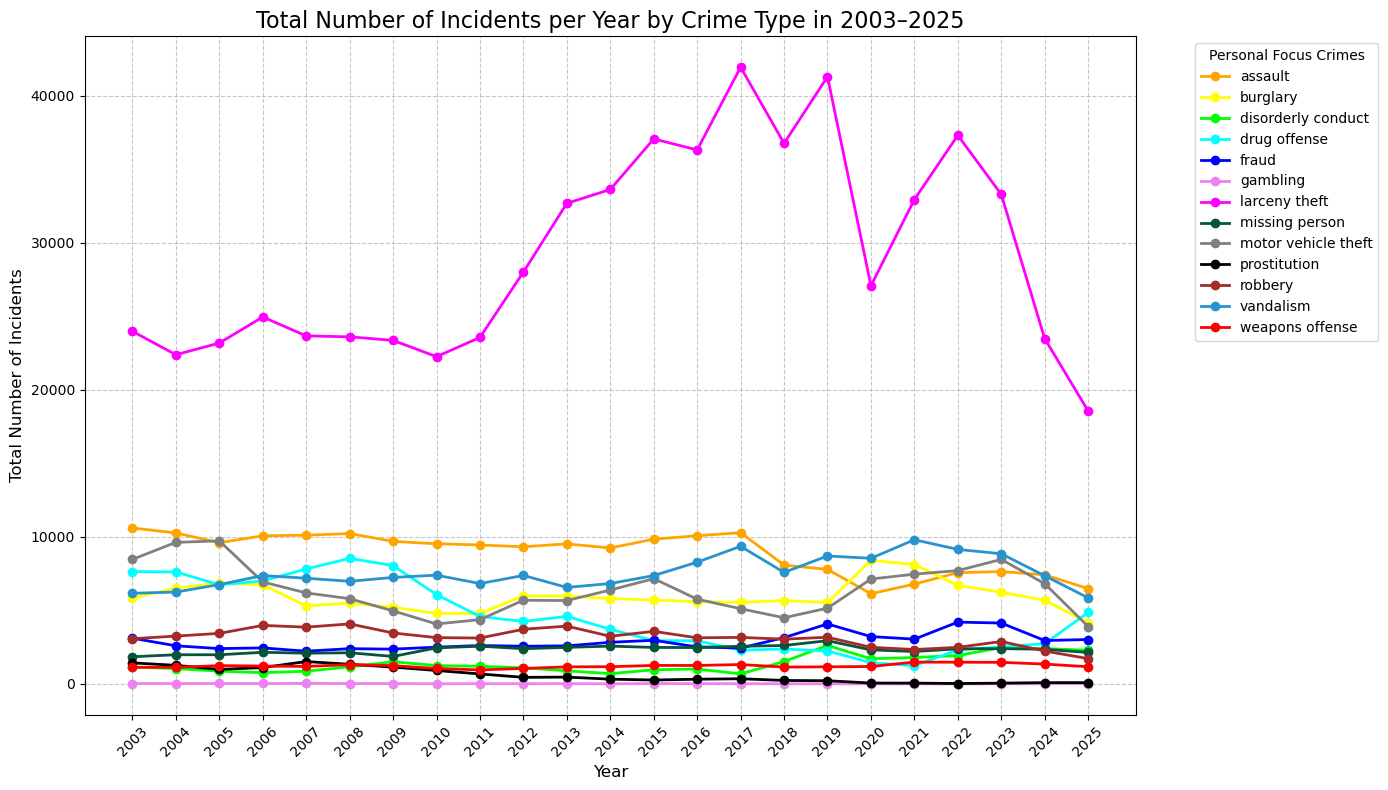

In [88]:
my_13_colors = [
    '#FFA500', '#FFFF00', '#00FF00', '#00FFFF', '#0000FF', 
    '#EE82EE', '#FF00FF', "#06543b", '#808080', '#000000', 
    '#A52A2A', "#2893CC", '#FF0000'
]

plt.figure(figsize=(14, 8))

yearly_counts.plot(kind='line', marker='o', ax=plt.gca(), linewidth=2, color=my_13_colors )

plt.title('Total Number of Incidents per Year by Crime Type in 2003–2025', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Number of Incidents', fontsize=12)
plt.xticks(range(2003, 2026), rotation=45) 
plt.legend(title='Personal Focus Crimes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Larceny theft(magenta) is far more fluctuative and most frequent crime in our Personal Focus Crime dataset. It rose drammatically  from 2011 - 2017 and reached more than 40000 incidents.  And it crushed suddenly in 2020. The sudden drop in 2020 clearly shows the impact of COVID-19. During pandemic, opportunities for shoplifting and pickpocketing are disappeared because of lockdowns and massive decrease in tourisim etc.
Most of the crime types incident numbers decreased in 2020 except burglary and motor vehicle theft. The reason for increasing motor vehicle theft (grey) might be remote work and stay at home rules. Cars owners parked their car in streets for weeks at a time. Those cars became a target for thieves.


Drug offenses (light blue) & prostitution(black)showed long term downward trend. These crimes peak  around 2007–2008 and then steadily drops for more than 10 years. This more than 10 years decline usually points to legislative changes rather than a sudden change in human behavior.

---
## Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from*: Week 3, Exercises 2.1 and 2.2.

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.
> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)
> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

The historical data uses ALL CAPS for district (`PARK`, `BAYVIEW`) while the recent data uses Title Case (`Park`, `Bayview`). We will fix this with `.str.upper()` or `.str.lower()`.

In [89]:
df['district'] = df['district'].str.lower().str.strip()

We need to understand how common a crime is in a specific district vs how common it is across the entire San Fransisco?

In [90]:
crime_numbers_by_district = df.groupby(['district', 'crime']).size().unstack(fill_value=0)
crime_numbers_by_district

crime,assault,burglary,disorderly conduct,drug offense,fraud,gambling,larceny theft,missing person,motor vehicle theft,prostitution,robbery,vandalism,weapons offense
district,,,,,,,,,,,,,
bayview,23773,13105,2847,7944,4156,57,40688,6079,21487,111,8033,19577,5088
central,20803,17247,3170,4252,9471,65,111477,4051,11584,1523,7675,21845,2029
ingleside,19292,12453,2076,4143,5371,60,40073,5637,23052,77,8023,17989,3379
mission,31680,15425,5928,17465,7520,47,70200,6690,19791,6337,11665,21457,4455
northern,23151,21902,3857,9149,8505,23,112415,4904,16758,3015,8491,23102,2564
out of sf,314,123,136,202,1183,0,3316,632,682,1,182,155,241
park,8466,10096,1501,4449,3274,2,36914,6218,9775,22,2524,9521,970
richmond,7845,9989,1704,1774,4610,12,47947,2595,10303,56,2496,11362,863
southern,33678,18272,4429,18531,10943,41,124543,7471,14191,442,11433,25198,3694


Let's calculate the conditional crime profile

In [91]:
district_totals = crime_numbers_by_district.sum(axis=1) # Total crime numbers per district
crime_totals = crime_numbers_by_district.sum(axis=0)    # Total crime numbers per crime type 
grand_total = crime_totals.sum()                    # Overall total crime numbers

# to compute ratio = P(crime | district) / P(crime)

# P(crime | district) =  Out of all crimes in Bayview, what percentage are assault?
# Total number of assault in Bayview / Total numbers of all crimes in Bayview

p_crime_district  = crime_numbers_by_district.div(district_totals, axis=0) #column wise

# P(crime) = (Total numbers of assault in entire city) / (Overall total crime numbers
p_crime = crime_totals / grand_total


ratio = p_crime_district.div(p_crime, axis=1)

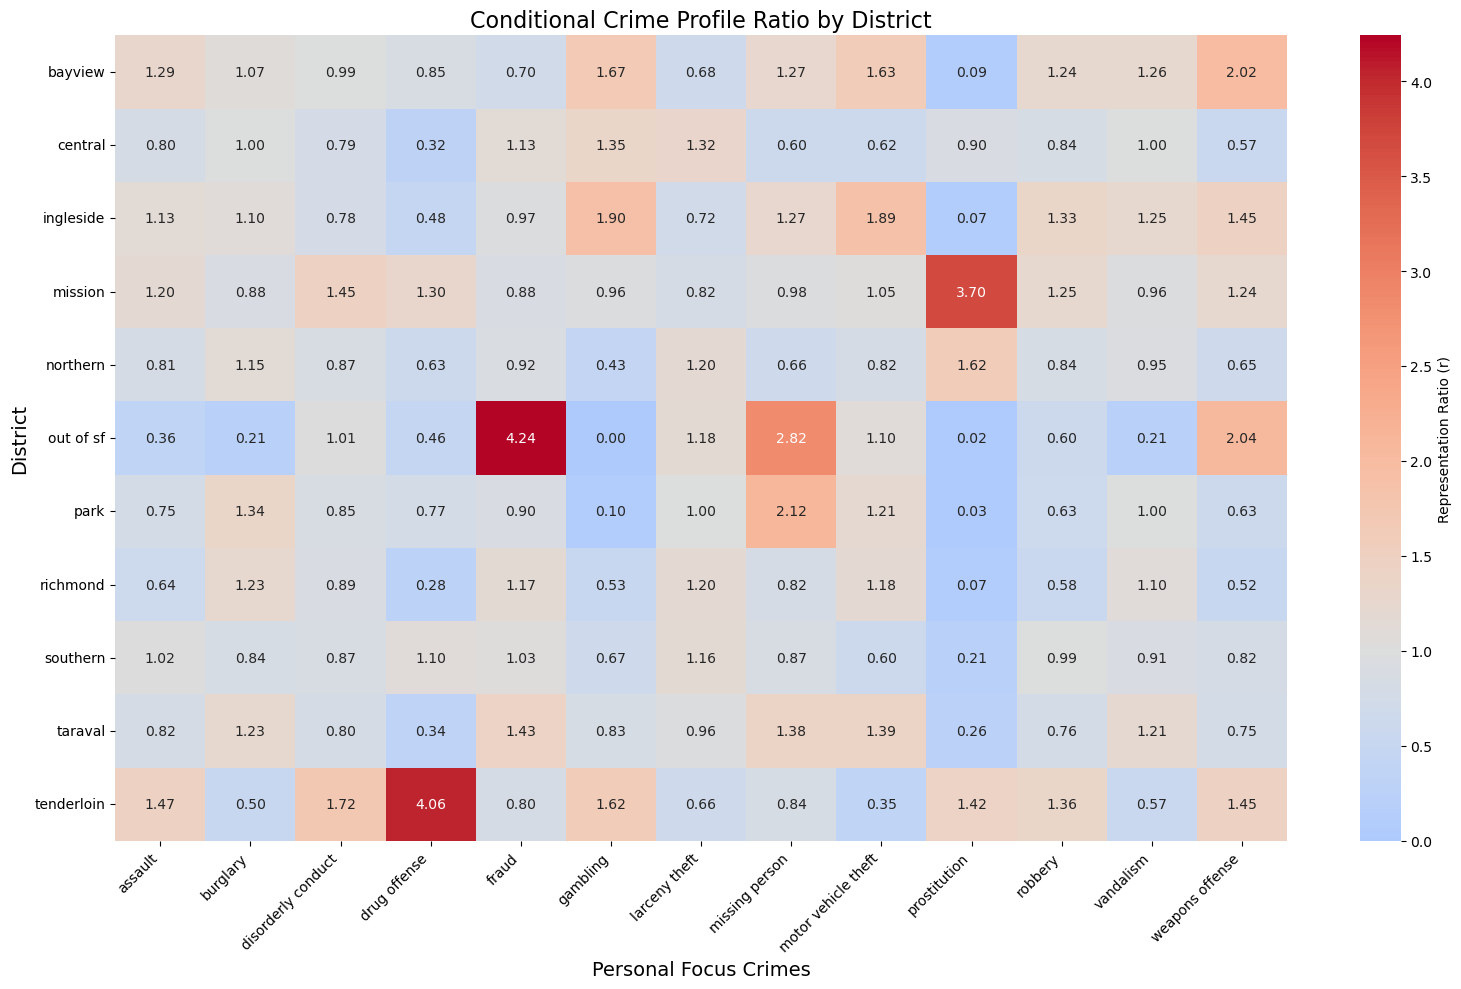

In [93]:
plt.figure(figsize=(16, 10))

# Centered at 1
# Red/Warm colors = > 1 (Over-represented)
# Blue/Cool colors < 1 (Under-represented)
sns.heatmap(ratio, annot=True, fmt=".2f", cmap="coolwarm", center=1.0, cbar_kws={'label': 'Representation Ratio (r)'})

plt.title('Conditional Crime Profile Ratio by District', fontsize=16)
plt.xlabel('Personal Focus Crimes', fontsize=14)
plt.ylabel('District', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, ha='right')
plt.tight_layout()

plt.show()

When looking at the heatmap Tenderloin district clearly stood out to us because its crime profile. Street level crimes like drug offense, assault and prostitution are over-represented compared to other districts. Tendorloin is clearly worst in drug offense. r=4.06 its 4 time worst than other districts in San Fransico.
Disorderly conduct,  gambling, robbery and weapons offense crime types are also over-represented. However, motor vehicle theft and burglary crimes are suprisingly underrepresented compared other districts. 

High level of drug offense activity (4.06) in streets can lead to confrontations and disorder and resulting in high rates of assault(1.47) and disorderly conduct(1.72) in the region.

We have checked the demographic data:
While 10.6% of people live below the poverty line across San Francisco, this is almost double in Tenderloin, 19.6%. [1][2]

While the median household income across the city is $141,446, this drops to $88,491 in Tenderloin. [1][2]

Economic inequality and poverty may lead the region to choose illegal economic activities (drug sales and prostitution)

On the other hand,
    
While the percentage of non-family households in San Francisco is 53.2% and the average number of people per household is 2, in Tenderloin the percentage of non-family households jumps to 73.7% and the average household size is just 1 person.
San Fransisco consists 18.2% detached, single-family homes while Tenderloin consists  only 1.7%. 50% of housing in Tenderloin consists of massive apartment complexes with 50 or more units. Housing in Tenderloin is not easy to access for robert this naturally lowers burglary rates. [1][2]

While 34.6% of people in San Francisco drive to work, only 10% walk. However, in Tenderloin, the percentage of people who drive to work drops to 27.2%, while the percentage of those who walk is a remarkable 33.4%. The low rate of car ownership and use in the area means there are fewer  vehicles available for theft. This  explains why hemotor vehicle theft rate is low. [1][2]
    


[1]  https://www.point2homes.com/US/Neighborhood/CA/San-Francisco-County/San-Francisco/Tenderloin-Demographics.html

[2]  https://www.point2homes.com/US/Neighborhood/CA/San-Francisco-Demographics.html#income

---
## Assignment 1.3: Visualizing Distributions

This exercise asks you to recreate several classic plot types from DAOST Chapter 2 using your own crime data — putting visualization theory into practice.

*Draws from*: Week 3, Exercises 5.2 and 5.3.

> **Part A — Jitter plot**
> * Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the $x$-axis and add vertical jitter.
> * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?
>
> **Part B — Probability plot**
> * Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (`scipy.stats.probplot` is your friend here.)
> * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?
>
> **Part C — Box plots of time-of-day**
> * For each of your Personal Focus Crimes, extract the time-of-day of every incident.
> * Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
> * What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
> * Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

---
## Assignment 1.4: Spatial Power Law

Is crime spread evenly across San Francisco, or is it concentrated in a small number of hotspots? Let's find out.

*Draws from*: Week 4, Exercise 2.2.

Use your **most common Personal Focus Crime** (by total incident count) for this exercise.

> * **Step 1**: Divide San Francisco into a grid of approximately $100\text{m} \times 100\text{m}$ cells using latitude and longitude. It is fine to ignore that the Earth isn't flat — the approximation is good enough for this purpose.
>     * **Hint**: `np.histogram2d` works well here. Focus on points within the SF peninsula; filter out geographic outliers.
> * **Step 2**: Count the number of incidents of your chosen crime in each grid cell (use all years of data).
> * **Step 3**: Tally the distribution. Count how many cells have exactly $k$ incidents — call this $N(k)$ — for $k = 0, 1, 2, \ldots$ up to the maximum.
> * **Step 4**: Plot $(k+1)$ vs $N(k)$ on **linear axes**.
> * **Step 5**: Plot $(k+1)$ vs $N(k)$ on **loglog axes**.
> * **Step 6**: Does your crime follow a power-law spatial distribution? How can you tell from the loglog plot?
> * **Step 7**: If crime is spatially concentrated in a small number of cells, what does that imply for how we interpret neighborhood-level crime statistics? Does the "average block" tell you anything useful?

---
## Assignment 1.5: Regression and Correlation

Which of your Personal Focus Crimes share the most similar weekly rhythm — and which are completely out of sync?

*Draws from*: Week 4, Exercises 3.1, 3.2, and 3.3.

Select **at least 4** of your Personal Focus Crimes for this exercise. More is fine - if you want to be closer to the actual weekly exercise.

> * For each selected crime type, compute the total number of incidents for each of the **168 hours of the week** (i.e., Monday 00:00–01:00, Monday 01:00–02:00, ..., Sunday 23:00–00:00). Each crime type will give you a vector of 168 values.
>
> * **Scatterplot matrix**: Create a grid of pairwise scatterplots — one panel per pair of crime types, with one crime on each axis and each of the 168 hours as a point. Label each panel clearly with the two crime types being compared.
>
> * **Linear regression**: Using the closed-form equations from Week 4 (not a library), fit a regression line $y = ax + b$ to each pair and add it to the relevant panel:
>   $$a = \frac{\sum_i x_i y_i - N\langle x\rangle\langle y\rangle}{\sum_i x_i^2 - N\langle x\rangle^2}, \qquad b = \langle y \rangle - a\langle x \rangle$$
>
> * **$R^2$**: Compute $R^2$ for each pair and display the value on each panel. 
>
> * Looking at your results: which pair of crimes is **most correlated**? Which is **least correlated**? Does the answer match your intuition? Why might two crime types share a weekly rhythm — or not?